In [7]:
%pip install qiskit==1.2.4
%pip install qiskit-aer==0.15.1
%pip install pylatexenc==2.10

from qiskit import QuantumCircuit
from qiskit.converters import circuit_to_gate
from qiskit.visualization import array_to_latex
from qiskit.quantum_info import Operator
from qiskit.quantum_info import Statevector
from qiskit import transpile
from qiskit.providers.basic_provider import BasicSimulator
from qiskit.visualization import plot_histogram
from qiskit.circuit import ControlledGate

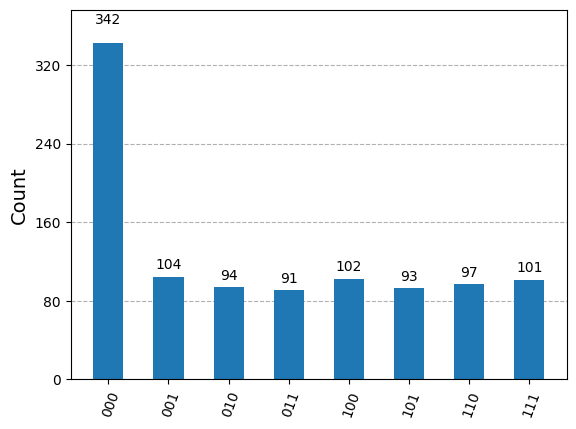

In [8]:
# Grover's algorithm
# Given a function f : {0,1}^n -> {0,1} such that for some input vector w,
# f(w) = 1 and for all x != w, f(x) = 0.
# The problem is to find w.

# Here we work with 3 qubits

# First we need a definition of f.

# Let's say f(0,0,0) = 1
# Try changing this to represent different search targets (you will need to change the definition of U, below)

# Then we need to define a unitary operator U on 3 qubits, such that
# U|x> = -|x> if f(x) = 1
# U|x> =  |x> if f(x) = 0

U = Operator([
   [-1, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 1, 0, 0, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 1]
])

# Now construct the Grover diffusion operator

G_matrix = list(map(lambda x: list(map(lambda y: y/4.0,x)),[
    [-3,1, 1, 1, 1, 1, 1, 1],
    [1,-3, 1, 1, 1, 1, 1, 1],
    [1, 1,-3, 1, 1, 1, 1, 1],
    [1, 1, 1,-3, 1, 1, 1, 1],
    [1, 1, 1, 1,-3, 1, 1, 1],
    [1, 1, 1, 1, 1,-3, 1, 1],
    [1, 1, 1, 1, 1, 1,-3, 1],
    [1, 1, 1, 1, 1, 1, 1,-3]
]))

G = Operator(G_matrix)

# Build a circuit with the correct number of iterations hard-coded, in this case 2

grover = QuantumCircuit(3)

# To get the initial state, apply H to every qubit

grover.h(0)
grover.h(1)
grover.h(2)

# Repeatedly apply U then G

grover.append(U,[0,1,2])
grover.append(G,[0,1,2])
grover.append(U,[0,1,2])
grover.append(G,[0,1,2])

# What if we do too many iterations?

#grover.append(U,[0,1,2])
#grover.append(G,[0,1,2])

# Measure all the qubits - to do that, we don't need to introduce classical bits

grover.measure_all()

# Simulate and plot results

backend = BasicSimulator()
compiled = transpile(grover, backend)
job_sim = backend.run(compiled, shots=1024)
result_sim = job_sim.result()
counts = result_sim.get_counts(compiled)
plot_histogram(counts)

### Current Circuit Explanation

1.  **Target State (`|000>`):** The `U` operator is defined to mark the `|000>` state with a phase flip (-1). This means `f(0,0,0) = 1`.
2.  **Diffusion Operator (`G`):** The `G_matrix` is constructed to create the Grover diffusion operator.
3.  **Circuit Construction:** The `grover` circuit starts with a Hadamard transformation on all qubits to create an equal superposition. Then, the `U` (oracle) and `G` (diffusion) operators are applied iteratively.
4.  **Iterations:** The current code applies `U` and `G` **twice**. For 3 qubits, the optimal number of iterations is typically around `pi/4 * sqrt(N/M)`, where N=2^n (n=number of qubits) and M=number of solutions. For a single solution with 3 qubits (N=8, M=1), this is approximately `pi/4 * sqrt(8) = 2.22`. So, 2 iterations are close to optimal.
5.  **Simulation:** The circuit is simulated using `BasicSimulator`, and the results are plotted as a histogram. As you can see from the plot, the `|000>` state has the highest probability, which is the expected outcome.

### Experimenting with Number of Iterations

**Too few iterations:** Try commenting out one pair of `grover.append(U,[0,1,2])` and `grover.append(G,[0,1,2])` from the code above, so that only one iteration is performed. Run the cell again and observe the histogram. You should see that the probability of `|000>` is lower.

**Too many iterations:** The commented-out lines `grover.append(U,[0,1,2])` and `grover.append(G,[0,1,2])` at the end of the iterations section allow you to add a third iteration. Uncomment these lines, run the cell, and observe the histogram. You should see that the probability of `|000>` might decrease, and other states might have higher probabilities, indicating that the amplification has 'overshot' the target.

### Changing the Search Value (Target State)

To change the search value, you need to modify the `U` operator so that it applies a phase flip to a different target state. Remember that `U|x> = -|x>` if `f(x)=1` and `U|x> = |x>` if `f(x)=0`.

For example, to search for the state `|101>` (which corresponds to index 5 in a little-endian representation, so the 6th row/column in the matrix starting from 0):

1.  **Identify the index:** For `|101>`, the binary number is `101`, which is `1*2^2 + 0*2^1 + 1*2^0 = 4 + 0 + 1 = 5`. So, the element at index 5 needs to be -1.

2.  **Modify the `U` matrix:** Change the `U` matrix definition to reflect this new target. For example, to target `|101>`:

    ```python
    U = Operator([
       [1, 0, 0, 0, 0, 0, 0, 0], # |000>
        [0, 1, 0, 0, 0, 0, 0, 0], # |001>
        [0, 0, 1, 0, 0, 0, 0, 0], # |010>
        [0, 0, 0, 1, 0, 0, 0, 0], # |011>
        [0, 0, 0, 0, 1, 0, 0, 0], # |100>
        [0, 0, 0, 0, 0, -1, 0, 0], # |101> <--- This is the new target
        [0, 0, 0, 0, 0, 0, 1, 0], # |110>
        [0, 0, 0, 0, 0, 0, 0, 1]  # |111>
    ])
    ```

    **Action:** Go back to the cell where `U` is defined (`c16cd3de-f076-496b-8661-4b1efd19a244`), modify it as shown above to target `|101>`, and then run all subsequent cells to see the new results. The histogram should now show `|101>` as the most probable outcome.